# Pattern Clustering using Cooperative Game Theory

Implementation of **DRAC (Density-Restricted Agglomerative Clustering)** from:
> Dhamal, S., Bhat, S., Anoop K R, & Embar, V. R. (2012). *Pattern Clustering using Cooperative Game Theory.*
> Centenary Conference, Electrical Engineering, IISc Bangalore.

The algorithm formulates clustering as a cooperative game and uses the **Shapley value** as a density proxy to guide agglomerative cluster growth.

**Dataset:** `complex9` — 9 clusters of varying density and shape.  
Source: https://github.com/deric/clustering-benchmark/blob/master/src/main/resources/datasets/artificial/complex9.arff

**Code:** This notebook can be found at https://github.com/ayush4ise/Pattern-Clustering-With-Cooperative-Game-Theory

## 1. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from collections import deque

from sklearn.cluster import AgglomerativeClustering, DBSCAN, OPTICS, KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

COLORS = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
print("All libraries loaded.")

All libraries loaded.


## 2. Load and Explore the Dataset

In [ ]:
def load_arff(filepath):
    """
    Parse a minimal ARFF file and return features (X) and integer labels (y).

    Returns
    -------
    X : np.ndarray (n_samples, 2)  — 2-D point coordinates
    y : np.ndarray (n_samples,)    — integer ground-truth labels
    """
    rows = []
    in_data = False
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.lower() == '@data':
                in_data = True
                continue
            if in_data and line and not line.startswith('%'):
                parts = line.split(',')
                rows.append([float(parts[0]), float(parts[1]), int(parts[2])])
    data = np.array(rows)
    return data[:, :2], data[:, 2].astype(int)


X, y_true = load_arff('complex9.arff')
n_samples = len(X)
n_clusters_true = len(np.unique(y_true))
print(f"Dataset: {n_samples} points | 2 features | {n_clusters_true} true clusters")

Dataset: 3031 points | 2 features | 9 true clusters


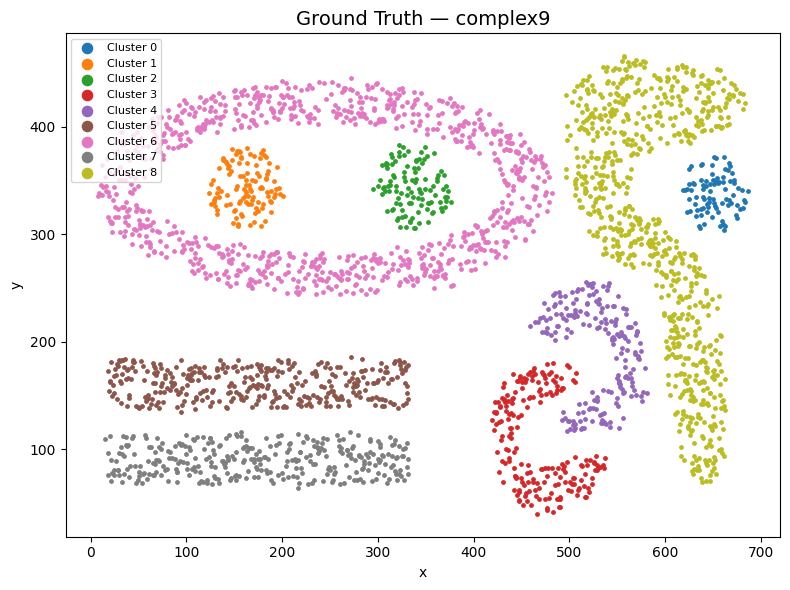

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
for label in np.unique(y_true):
    mask = y_true == label
    ax.scatter(X[mask, 0], X[mask, 1], s=6, color=COLORS[label], label=f'Cluster {label}')
ax.set_title('Ground Truth — complex9', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(markerscale=3, fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## 3. Core Game-Theory Utilities

The paper defines the characteristic function and Shapley value as:

$$\nu(S) = \frac{1}{2}\sum_{\substack{i,j \in S \\ i \neq j}} f(d(i,j)), \qquad
\phi_i = \frac{1}{2}\sum_{\substack{j \in N \\ j \neq i}} f(d(i,j))$$

We use a **Gaussian kernel** for $f$ so that Shapley values reflect *local* density:

$$f(d(i,j)) = \exp\!\left(-\frac{d(i,j)^2}{2\sigma^2}\right)$$

The paper defines the similarity as `f(d) = 1 - d/dM` where `dM` is the global maximum pairwise distance. This linear form has two practical problems on real datasets:

1. Shapley values reflect global centrality, not local density.
2. The threshold `beta` becomes meaningless. Since `f(d)` decays linearly, even distant points have non-negligible similarity, so clusters grow too aggressively and beta thresholds fail to control growth.

The fix is a **Gaussian (RBF) kernel** `f(d) = exp(-d^2 / 2*sigma^2)` with bandwidth `sigma` = mean 5-nearest-neighbour distance. This makes similarity decay to near-zero for distant points, so Shapley values capture local density and beta thresholds are genuinely selective.

In [ ]:
def pairwise_distances(X):
    """
    Compute the full Euclidean distance matrix for a 2-D point set.

    Parameters
    ----------
    X : np.ndarray (n, 2)

    Returns
    -------
    D : np.ndarray (n, n)  — symmetric, zero on diagonal
    """
    diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
    return np.sqrt((diff ** 2).sum(axis=-1))


def gaussian_similarity_matrix(D, k_nn=5):
    """
    Build a Gaussian (RBF) similarity matrix.

    f(d(i,j)) = exp(-d(i,j)^2 / (2 * sigma^2))

    The bandwidth sigma is the mean k-nearest-neighbour distance across all
    points, giving a scale that matches typical intra-cluster spacing rather
    than the global extent of the dataset.

    Parameters
    ----------
    D    : np.ndarray (n, n)  — Euclidean distance matrix
    k_nn : int                — neighbourhood size for bandwidth estimation

    Returns
    -------
    F     : np.ndarray (n, n)  — pairwise Gaussian similarities in (0, 1]
    sigma : float              — bandwidth used
    """
    sorted_D = np.sort(D, axis=1)       # column 0 is self (distance 0)
    sigma = sorted_D[:, k_nn].mean()    # mean k-th NN distance as bandwidth
    F = np.exp(-(D ** 2) / (2.0 * sigma ** 2))
    return F, sigma


def shapley_values(F):
    """
    Compute the Shapley value for each point using Equation (7) in the paper.

    phi_i = 0.5 * sum_{j != i} f(d(i, j))

    Parameters
    ----------
    F : np.ndarray (n, n)  — similarity matrix

    Returns
    -------
    phi : np.ndarray (n,)  — Shapley value (local density score) per point
    """
    F_no_diag = F.copy()
    np.fill_diagonal(F_no_diag, 0.0)
    return 0.5 * F_no_diag.sum(axis=1)


# Precompute once — shared by DRAC and SHARPC
D = pairwise_distances(X)
F, sigma = gaussian_similarity_matrix(D, k_nn=5)
phi = shapley_values(F)

print(f"Gaussian bandwidth sigma: {sigma:.2f}")
print(f"Shapley values — min: {phi.min():.2f}  max: {phi.max():.2f}  mean: {phi.mean():.2f}")
seed = int(np.argmax(phi))
print(f"First seed: coords=({X[seed,0]:.1f}, {X[seed,1]:.1f}), true label={y_true[seed]}")

Gaussian bandwidth sigma: 8.72
Shapley values — min: 0.82  max: 9.10  mean: 4.51
First seed: coords=(585.8, 290.9), true label=8


## 4. DRAC — Density-Restricted Agglomerative Clustering

**Algorithm 1** from the paper. Key ideas:
- Cluster centres are seeds with the highest Shapley values (densest local regions first).
- Each cluster grows via an *expansion queue*; a point joins the queue only if its Shapley value >= gamma * lM, preventing thin bridges from merging distinct clusters.
- The similarity threshold `beta = delta * sqrt(lM / gM)` scales with the centre's local density, so sparse clusters use looser thresholds.

In [31]:
def drac(F, phi, delta=0.45, gamma=0.3):
    """
    Density-Restricted Agglomerative Clustering (DRAC) — Algorithm 1 in the paper.

    Parameters
    ----------
    F     : np.ndarray (n, n)  — pairwise Gaussian similarity matrix
    phi   : np.ndarray (n,)    — Shapley values (local density scores)
    delta : float in [0, 1]    — maximum similarity threshold; higher = tighter clusters
    gamma : float in [0, 1]    — min Shapley fraction to enter expansion queue;
                                 higher = only dense-core points propagate growth

    Returns
    -------
    labels : np.ndarray (n,)  — cluster assignment; -1 means noise (singleton seed)
    """
    n = len(phi)
    labels    = np.full(n, -1, dtype=int)
    allocated = np.zeros(n, dtype=bool)

    g_M        = phi.max()               # global maximum Shapley value (Step 3)
    sorted_idx = np.argsort(phi)[::-1]   # descending order for seed selection
    sorted_ptr = 0

    cluster_id = 0

    while True:
        # Step 4: next unallocated point with highest Shapley value becomes cluster seed
        seed = -1
        while sorted_ptr < n:
            candidate = sorted_idx[sorted_ptr]
            sorted_ptr += 1
            if not allocated[candidate]:
                seed = candidate
                break

        if seed == -1:
            break   # all points allocated

        l_M  = phi[seed]
        beta = delta * np.sqrt(l_M / g_M)   # Step 5: adaptive threshold per cluster

        labels[seed]    = cluster_id
        allocated[seed] = True
        expansion_queue = deque([seed])
        cluster_size    = 1

        # Steps 6-8: grow cluster through expansion queue
        while expansion_queue:
            front = expansion_queue.popleft()   # Step 7

            for i in range(n):
                if allocated[i]:
                    continue
                # Step 6a: join cluster if similar enough to the current queue-front point
                if F[front, i] >= beta:
                    labels[i]    = cluster_id
                    allocated[i] = True
                    cluster_size += 1
                    # Step 6b: enqueue only if dense enough to propagate further growth
                    if phi[i] >= gamma * l_M:
                        expansion_queue.append(i)

        # Step 9: singleton seeds are noise, not a real cluster
        if cluster_size == 1:
            labels[seed] = -1
        else:
            cluster_id += 1

        if allocated.all():
            break   # Step 10

    return labels


labels_drac = drac(F, phi, delta=0.35, gamma=0.2)
n_found = len(set(labels_drac) - {-1})
n_noise = int((labels_drac == -1).sum())
print(f"DRAC found {n_found} clusters | {n_noise} noise points")

DRAC found 9 clusters | 3 noise points


## 5. Benchmark Algorithms

### 5.1 SHARPC — Shapley-value K-means Initialisation

SHARPC (Garg, Narahari & Murthy, 2011) uses Shapley values to pick well-separated initial centres for K-means.

In [32]:
def sharpc(X, phi, F, k):
    """
    SHARPC: Shapley-value Based Robust Pattern Clustering (Garg et al., 2011).

    Greedily selects k diverse, high-density seeds: the first seed is the point
    with the highest Shapley value; each subsequent seed minimises its maximum
    similarity to the already-chosen centres (maximum-diversity seeding).
    K-means is then run from these seeds.

    Parameters
    ----------
    X   : np.ndarray (n, 2)  — point coordinates
    phi : np.ndarray (n,)    — Shapley values
    F   : np.ndarray (n, n)  — similarity matrix
    k   : int                — number of clusters

    Returns
    -------
    labels : np.ndarray (n,)  — K-means cluster assignments
    """
    n = len(phi)
    centers = [int(np.argmax(phi))]

    for _ in range(k - 1):
        # For each candidate, find its maximum similarity to any already-chosen center
        max_sim = np.array([max(F[i, c] for c in centers) for i in range(n)])
        # The next center is the point most dissimilar to all current centers
        centers.append(int(np.argmin(max_sim)))

    km = KMeans(n_clusters=k, init=X[centers], n_init=1, random_state=42)
    return km.fit_predict(X)


labels_sharpc = sharpc(X, phi, F, k=n_clusters_true)
print(f"SHARPC produced {len(np.unique(labels_sharpc))} clusters")

SHARPC produced 9 clusters


### 5.2 Agglomerative Clustering

In [33]:
# Ward linkage with the true k as stopping criterion
labels_agg = AgglomerativeClustering(n_clusters=n_clusters_true, linkage='ward').fit_predict(X)
print(f"Agglomerative Clustering: {len(np.unique(labels_agg))} clusters")

Agglomerative Clustering: 9 clusters


### 5.3 DBSCAN

In [34]:
# eps and min_samples chosen to match the variable-density structure of complex9
labels_dbscan = DBSCAN(eps=12, min_samples=5).fit_predict(X)
n_dbscan = len(set(labels_dbscan) - {-1})
print(f"DBSCAN: {n_dbscan} clusters | {(labels_dbscan == -1).sum()} noise points")

DBSCAN: 11 clusters | 14 noise points


### 5.4 OPTICS

In [35]:
# xi-based extraction handles clusters of different densities better than fixed eps
labels_optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.02).fit_predict(X)
n_optics = len(set(labels_optics) - {-1})
print(f"OPTICS: {n_optics} clusters | {(labels_optics == -1).sum()} noise points")

OPTICS: 15 clusters | 1599 noise points


## 6. Visualise All Results

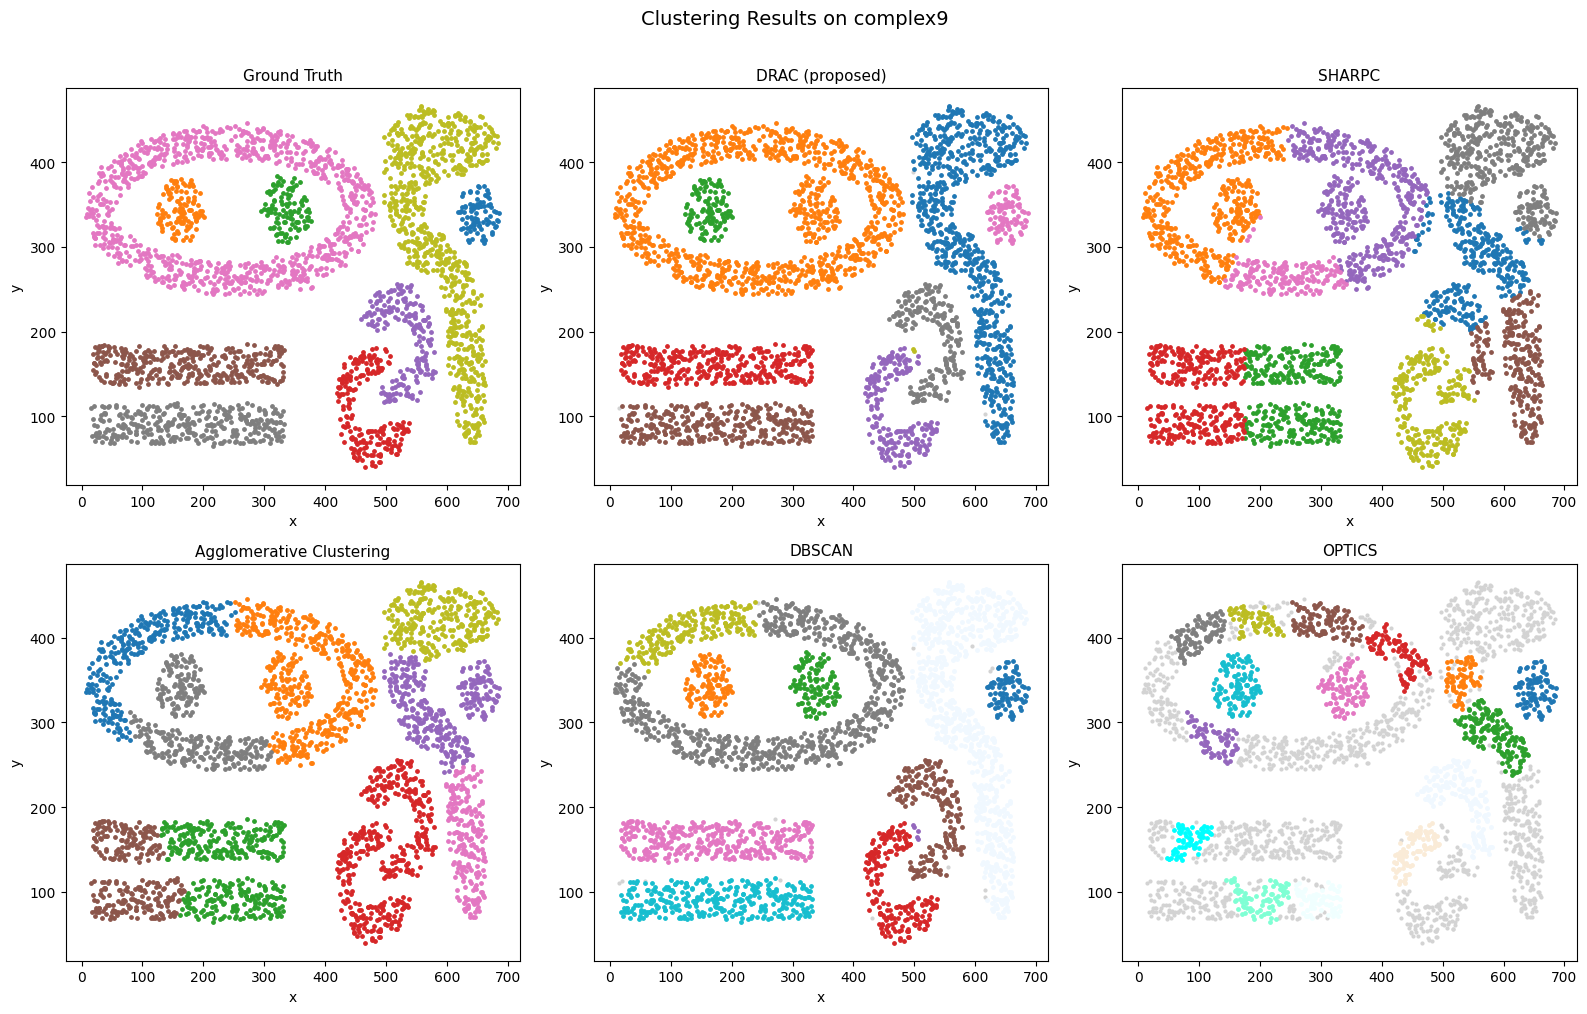

In [36]:
def plot_clusters(ax, X, labels, title):
    """
    Scatter-plot cluster assignments; noise points (-1) shown as small grey dots.

    Parameters
    ----------
    ax     : matplotlib Axes
    X      : np.ndarray (n, 2)
    labels : np.ndarray (n,)  — cluster labels; -1 = noise
    title  : str
    """
    for label in sorted(set(labels)):
        mask = labels == label
        if label == -1:
            ax.scatter(X[mask, 0], X[mask, 1], s=4, c='lightgrey', label='Noise')
        else:
            ax.scatter(X[mask, 0], X[mask, 1], s=6, color=COLORS[label % len(COLORS)])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('y')


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

all_results = [
    (y_true,        'Ground Truth'),
    (labels_drac,   'DRAC (proposed)'),
    (labels_sharpc, 'SHARPC'),
    (labels_agg,    'Agglomerative Clustering'),
    (labels_dbscan, 'DBSCAN'),
    (labels_optics, 'OPTICS'),
]

for ax, (labels, title) in zip(axes, all_results):
    plot_clusters(ax, X, labels, title)

plt.suptitle('Clustering Results on complex9', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Quantitative Evaluation

- **ARI (Adjusted Rand Index):** pair-wise agreement; 1.0 = perfect, 0 = random.
- **NMI (Normalised Mutual Information):** shared information; 1.0 = perfect.

In [37]:
def evaluate(labels_pred, labels_true, name):
    """
    Compute ARI and NMI, excluding noise points from the evaluation.

    Parameters
    ----------
    labels_pred : np.ndarray (n,)  — predicted cluster labels
    labels_true : np.ndarray (n,)  — ground-truth labels
    name        : str

    Returns
    -------
    dict with keys: Algorithm, Clusters, Noise, ARI, NMI
    """
    valid = labels_pred != -1    # exclude noise so noise labelling doesn't skew scores
    ari = adjusted_rand_score(labels_true[valid], labels_pred[valid])
    nmi = normalized_mutual_info_score(labels_true[valid], labels_pred[valid])
    return {
        'Algorithm': name,
        'Clusters':  len(set(labels_pred) - {-1}),
        'Noise':     int((labels_pred == -1).sum()),
        'ARI':       round(ari, 4),
        'NMI':       round(nmi, 4),
    }


df_results = pd.DataFrame([
    evaluate(labels_drac,   y_true, 'DRAC (proposed)'),
    evaluate(labels_sharpc, y_true, 'SHARPC'),
    evaluate(labels_agg,    y_true, 'Agglomerative Clustering'),
    evaluate(labels_dbscan, y_true, 'DBSCAN'),
    evaluate(labels_optics, y_true, 'OPTICS'),
]).set_index('Algorithm')

print(df_results.to_string())

                          Clusters  Noise     ARI     NMI
Algorithm                                                
DRAC (proposed)                  9      3  0.9309  0.9678
SHARPC                           9      0  0.3918  0.6504
Agglomerative Clustering         9      0  0.4222  0.7052
DBSCAN                          11     14  0.8842  0.9566
OPTICS                          15   1599  0.5669  0.8582


## 8. DRAC Parameter Sensitivity

- **delta:** maximum similarity threshold — higher = tighter clusters.
- **gamma:** expansion queue multiplier — higher = only dense-core points propagate growth.

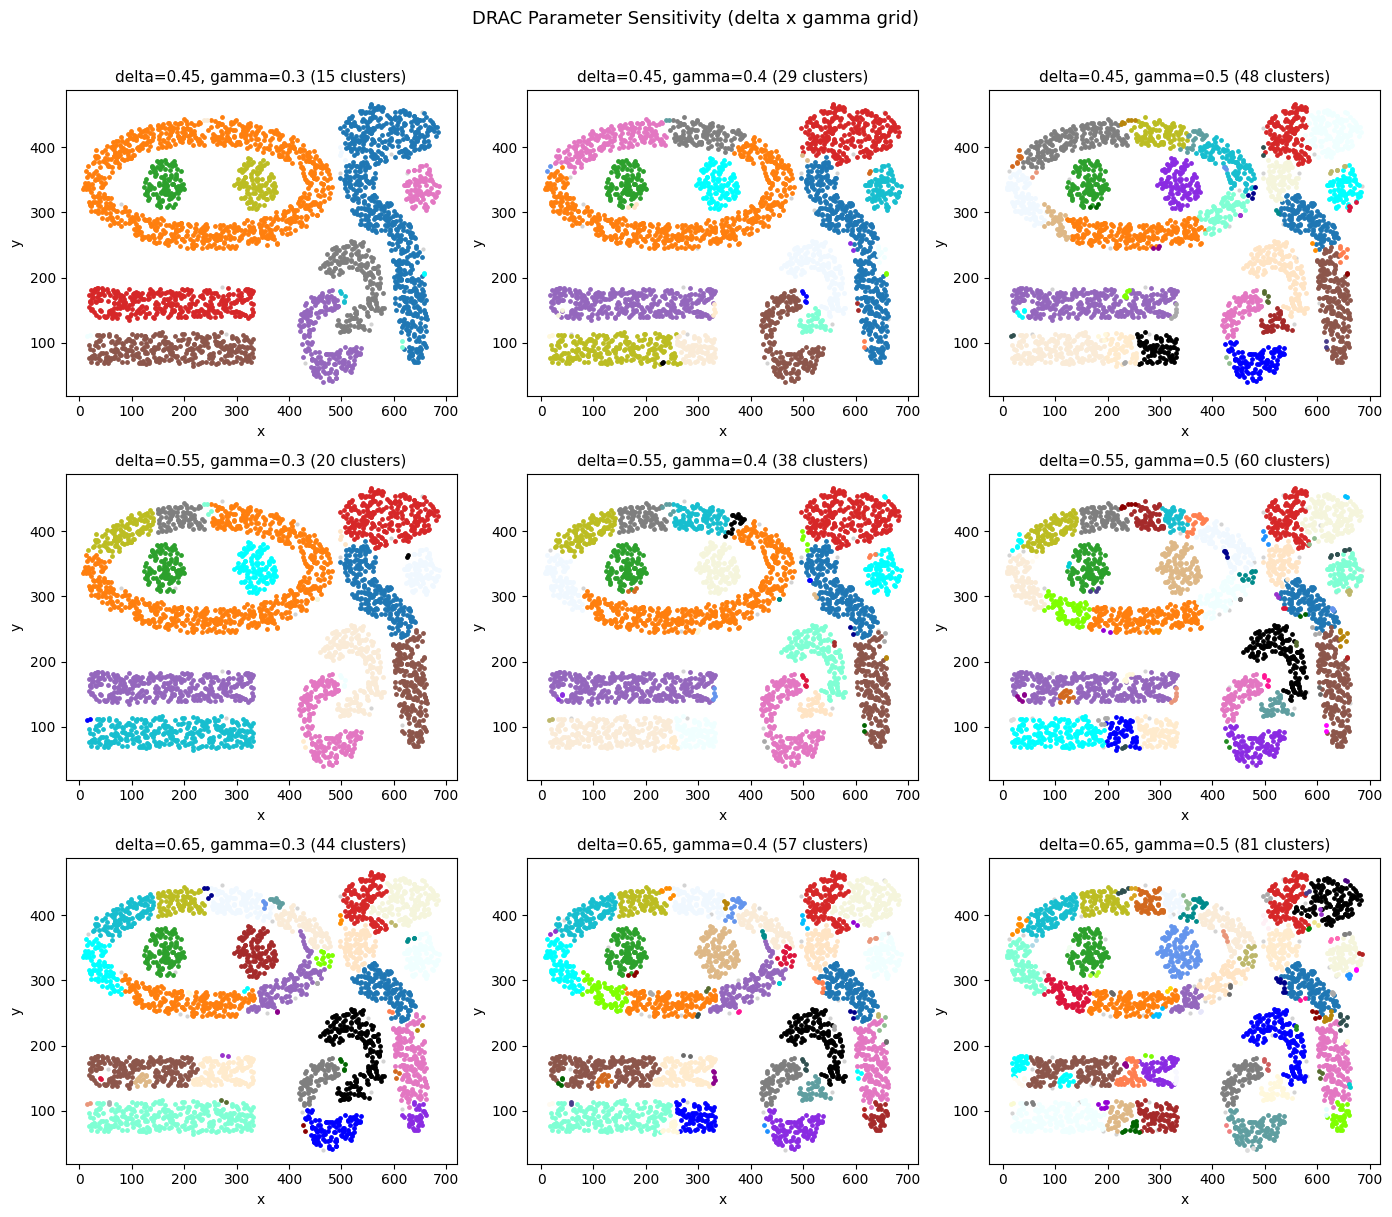

In [39]:
delta_vals = [0.45, 0.55, 0.65]
gamma_vals = [0.3,  0.4,  0.5]

fig, axes = plt.subplots(len(delta_vals), len(gamma_vals), figsize=(14, 12))

for i, delta in enumerate(delta_vals):
    for j, gamma in enumerate(gamma_vals):
        lbl = drac(F, phi, delta=delta, gamma=gamma)
        k   = len(set(lbl) - {-1})
        plot_clusters(axes[i][j], X, lbl, f'delta={delta}, gamma={gamma} ({k} clusters)')

plt.suptitle('DRAC Parameter Sensitivity (delta x gamma grid)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()